In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


We see a positive and perfectly positve corellations marked above...The following heatmap is before cleaing the data

                      age    fnlwgt  educational-num  capital-gain  \
age              1.000000 -0.076628         0.030940      0.077229   
fnlwgt          -0.076628  1.000000        -0.038761     -0.003706   
educational-num  0.030940 -0.038761         1.000000      0.125146   
capital-gain     0.077229 -0.003706         0.125146      1.000000   
capital-loss     0.056944 -0.004366         0.080972     -0.031441   
hours-per-week   0.071558 -0.013519         0.143689      0.082157   

                 capital-loss  hours-per-week  
age                  0.056944        0.071558  
fnlwgt              -0.004366       -0.013519  
educational-num      0.080972        0.143689  
capital-gain        -0.031441        0.082157  
capital-loss         1.000000        0.054467  
hours-per-week       0.054467        1.000000  


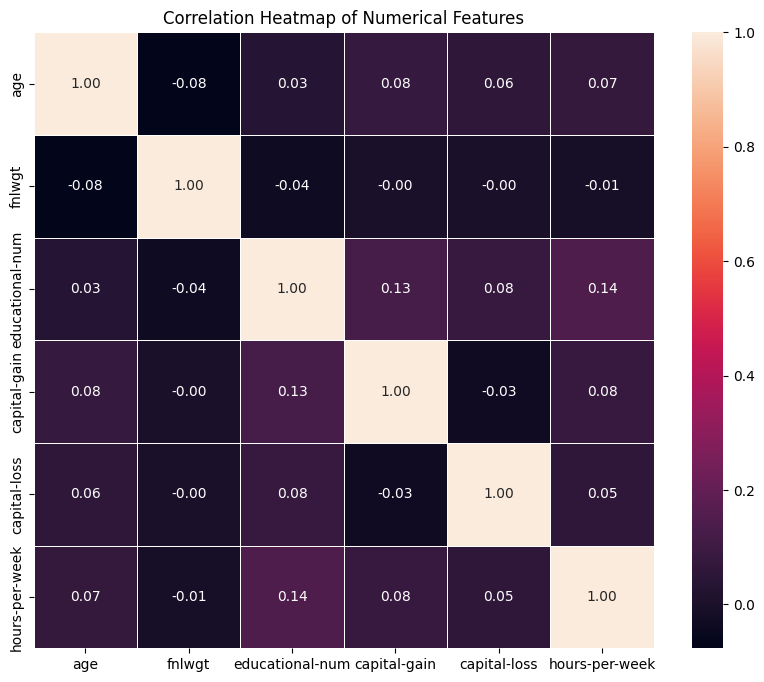

In [5]:

df = pd.read_csv('adult.csv')
numerical_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numerical_df.corr()
print(corr_matrix)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


Cleaning the data below...

In [6]:

df = df.replace('?', np.nan)
print(df.isnull().sum())

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64


In [7]:
df = df.dropna()

Plotting the data after a cleaning the data. There are changes in corellations

                      age    fnlwgt  educational-num  capital-gain  \
age              1.000000 -0.075792         0.037623      0.079683   
fnlwgt          -0.075792  1.000000        -0.041993     -0.004110   
educational-num  0.037623 -0.041993         1.000000      0.126907   
capital-gain     0.079683 -0.004110         0.126907      1.000000   
capital-loss     0.059351 -0.004349         0.081711     -0.032102   
hours-per-week   0.101992 -0.018679         0.146206      0.083880   

                 capital-loss  hours-per-week  
age                  0.059351        0.101992  
fnlwgt              -0.004349       -0.018679  
educational-num      0.081711        0.146206  
capital-gain        -0.032102        0.083880  
capital-loss         1.000000        0.054195  
hours-per-week       0.054195        1.000000  


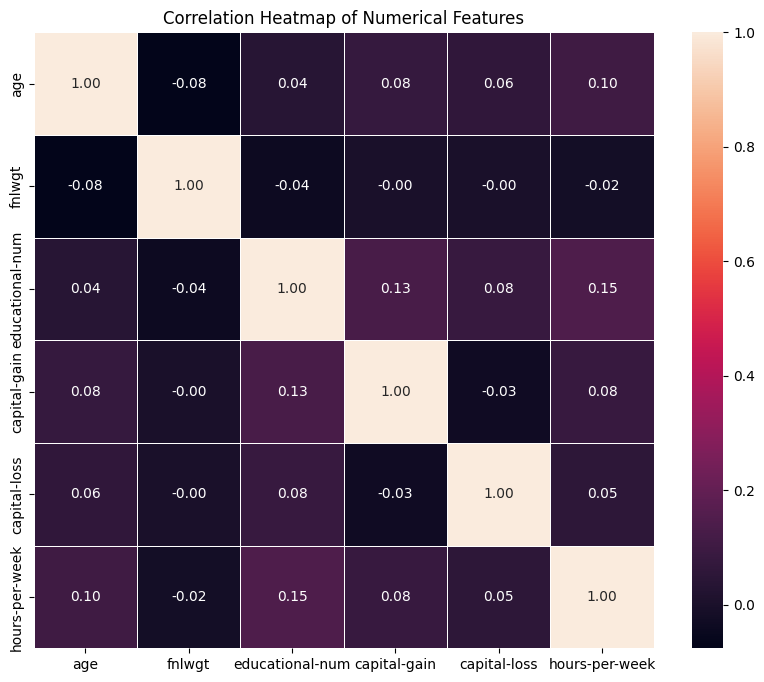

In [8]:
numerical_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numerical_df.corr()
print(corr_matrix)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


Histogram of distributions of age, hours and education levels is plotted below whith an outile of its pdf

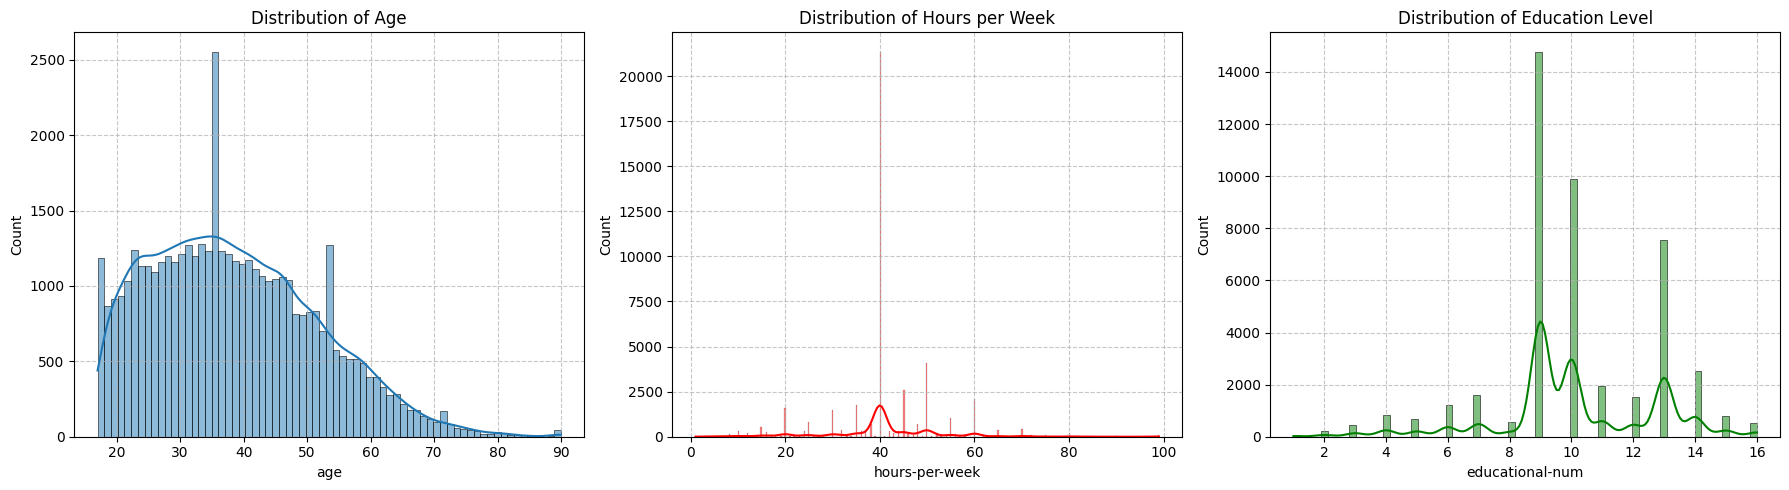

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['age'], ax=axes[0], kde=True)

axes[0].set_title('Distribution of Age')
sns.histplot(df['hours-per-week'], ax=axes[1], kde=True, color='red')

axes[1].set_title('Distribution of Hours per Week')
sns.histplot(df['educational-num'], ax=axes[2], kde=True, color='green')
plt.grid(True)
axes[2].set_title('Distribution of Education Level')
for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

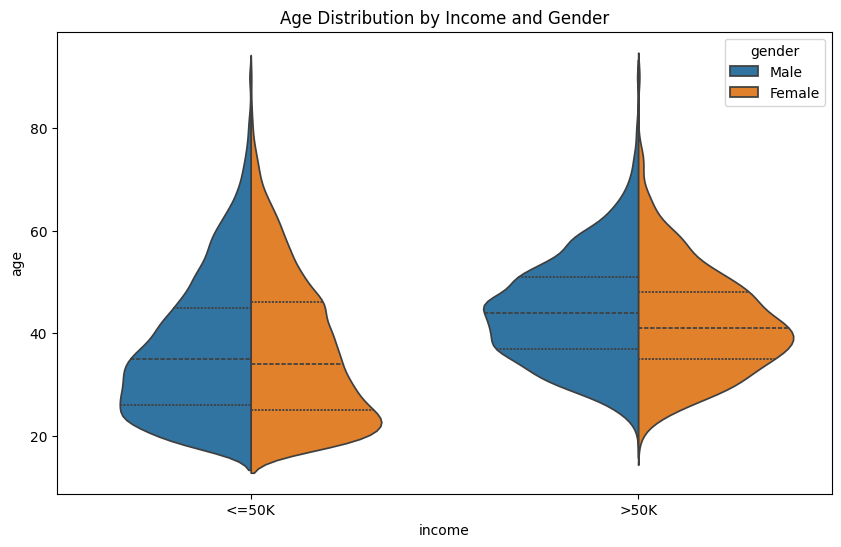

In [10]:
plt.figure(figsize=(10, 6))

sns.violinplot(data=df, x='income', y='age', hue='gender', split=True, inner="quartile")
plt.title('Age Distribution by Income and Gender')
plt.show()


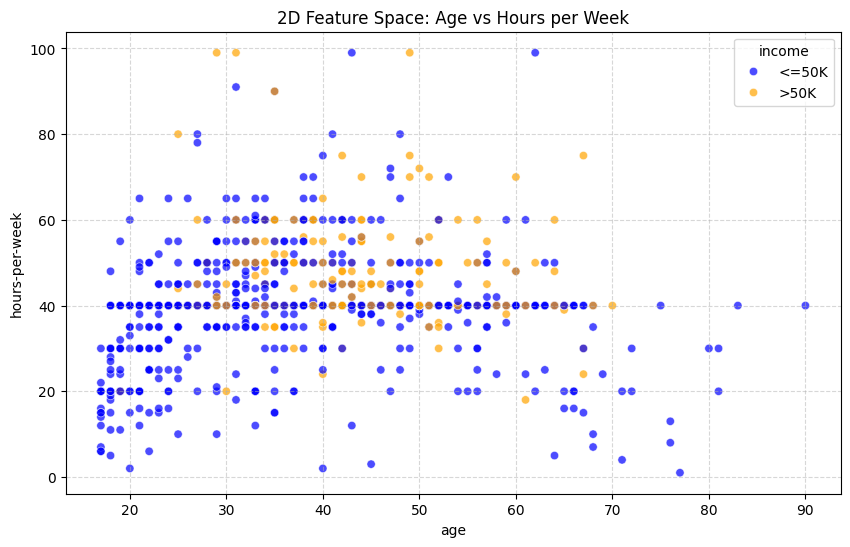

In [ ]:
plt.figure(figsize=(10, 6))
df_sample = df.sample(n=1000, random_state=42)
sns.scatterplot(
    data=df_sample, 
    x='age', 
    y='hours-per-week', 
    hue='income',
    alpha=0.7,  
    palette={'<=50K': 'blue', '>50K': 'orange'}
)


plt.title('Age vs Hours per Week')
plt.grid(True, linestyle='--', alpha=0.5)

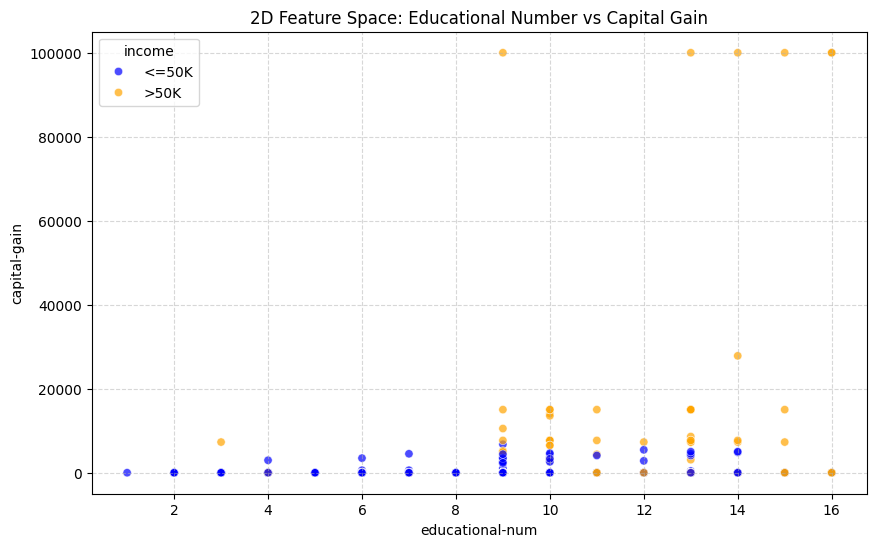

In [ ]:
plt.figure(figsize=(10, 6))
df_sample = df.sample(n=1000, random_state=42)
sns.scatterplot(
    data=df_sample, 
    x='educational-num', 
    y='capital-gain', 
    hue='income',

    alpha=0.7,  
    palette={'<=50K': 'blue', '>50K': 'orange'}
)


plt.title('Educational Number vs Capital Gain')
plt.grid(True, linestyle='--', alpha=0.5)

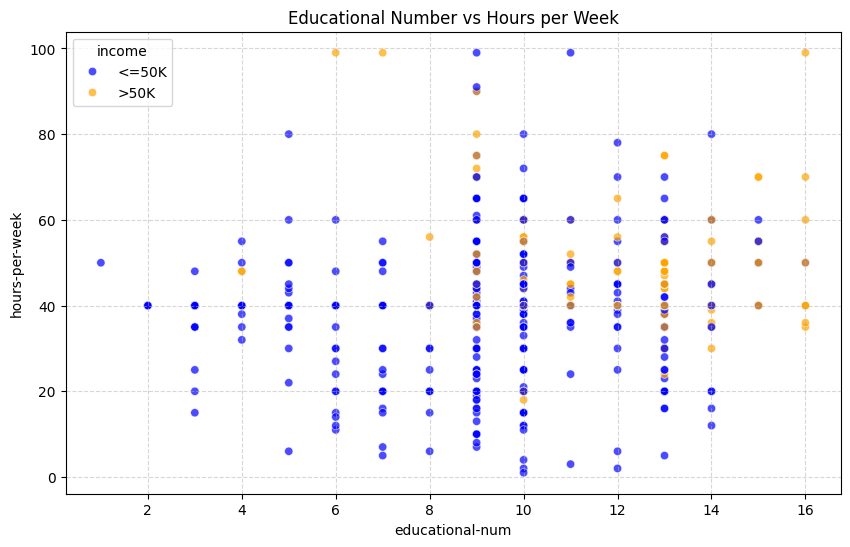

In [14]:
plt.figure(figsize=(10, 6))
df_sample = df.sample(n=1000, random_state=42)
sns.scatterplot(
    data=df_sample, 
    x='educational-num', 
    y='hours-per-week', 
    hue='income',

    alpha=0.7,  
    palette={'<=50K': 'blue', '>50K': 'orange'}
)


plt.title('Educational Number vs Hours per Week')
plt.grid(True, linestyle='--', alpha=0.5)

since the target is ">50k" and "<50k" which r strings, we need a label encoder to convert it into 0s and 1s

In [ ]:

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


X = df.drop('income', axis=1)


y_raw = df['income']

le = LabelEncoder()
y = le.fit_transform(y_raw)

numerical_features = ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical_features = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    sparse_threshold=0 
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

classifiers = {
    'Manhattan': KNeighborsClassifier(n_neighbors=5, metric='manhattan'),
    'Euclidean': KNeighborsClassifier(n_neighbors=5, metric='euclidean'),
    'Chebyshev': KNeighborsClassifier(n_neighbors=5, metric='chebyshev')
}

print("--- Accuracy Comparison by Distance Metric ---")

for name, clf in classifiers.items():
    current_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])
    
    current_pipeline.fit(X_train, y_train)
    y_pred = current_pipeline.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    print(f"Metric: {name:<12} | Accuracy: {acc:.4f}")

--- Accuracy Comparison by Distance Metric ---
Metric: Manhattan    | Accuracy: 0.8290
Metric: Euclidean    | Accuracy: 0.8295
Metric: Chebyshev    | Accuracy: 0.8199


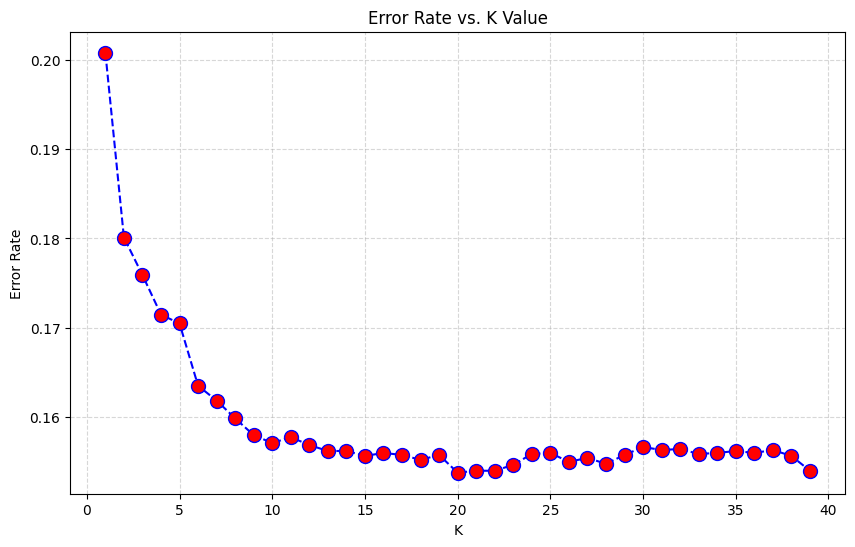

0.15400773908236595
0.15400773908236595


In [ ]:
error_rate = []

for i in range (1, 40):
    
    knn = KNeighborsClassifier(n_neighbors=i, metric='euclidean')
    
    
    current_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', knn)
    ])
    
    
    current_pipeline.fit(X_train, y_train)
    pred_i = current_pipeline.predict(X_test)
    
    
    error_rate.append(np.mean(pred_i != y_test))


plt.figure(figsize=(10,6))
plt.plot(range(1, 40), error_rate, color='blue', linestyle='dashed', 
         marker='o', markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
